# 📦 Install & Load Data

Dataset yang digunakan adalah **MInDS-14** (*Multilingual Intent Detection and Slot Filling*), subset bahasa **en-US**, yang tersedia secara publik di Hugging Face.

> 🔗 Source: [https://huggingface.co/datasets/PolyAI/minds14](https://huggingface.co/datasets/PolyAI/minds14)

Dataset ini berisi rekaman audio pendek dari pengguna yang berinteraksi dengan sistem perbankan otomatis. Setiap sampel dilengkapi dengan:
- `audio` — array waveform + sampling rate
- `transcription` — transkripsi asli (dalam bahasa asal)
- `english_transcription` — terjemahan Bahasa Inggris
- `intent_class` — label intent (14 kelas)
- `lang_id` — kode bahasa

Cell ini menginstall semua library yang dibutuhkan dan melakukan import awal.

In [ ]:
# Install required libraries
!pip install transformers datasets evaluate jiwer librosa accelerate torchaudio wordcloud -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
from wordcloud import WordCloud
from collections import Counter
import re
import warnings
warnings.filterwarnings("ignore")

from datasets import load_dataset, Audio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.5 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset, Audio

# Load en-US subset
dataset = load_dataset("PolyAI/minds14", name="en-US")

# Basic inspection
print("=== SPLITS ===")
print(dataset)

print("\n=== FEATURES ===")
print(dataset["train"].features)

print("=== FIRST SAMPLE (raw) ===")
sample = dataset["train"][0]

for key, val in sample.items():
    if key != "audio":
        print(f"{key}: {val}")

# Access audio separately after decoding
audio_data = sample["audio"]
print(f"\naudio sampling_rate : {audio_data['sampling_rate']} Hz")
print(f"audio array shape   : {audio_data['array'].shape}")
print(f"audio array dtype   : {audio_data['array'].dtype}")
print(f"audio duration      : {len(audio_data['array']) / audio_data['sampling_rate']:.2f}s")

README.md: 0.00B [00:00, ?B/s]

en-US/train-00000-of-00001.parquet:   0%|          | 0.00/34.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/563 [00:00<?, ? examples/s]

=== SPLITS ===
DatasetDict({
    train: Dataset({
        features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
        num_rows: 563
    })
})

=== FEATURES ===
{'path': Value('string'), 'audio': Audio(sampling_rate=8000, decode=True, stream_index=None), 'transcription': Value('string'), 'english_transcription': Value('string'), 'intent_class': ClassLabel(names=['abroad', 'address', 'app_error', 'atm_limit', 'balance', 'business_loan', 'card_issues', 'cash_deposit', 'direct_debit', 'freeze', 'high_value_payment', 'joint_account', 'latest_transactions', 'pay_bill']), 'lang_id': ClassLabel(names=['cs-CZ', 'de-DE', 'en-AU', 'en-GB', 'en-US', 'es-ES', 'fr-FR', 'it-IT', 'ko-KR', 'nl-NL', 'pl-PL', 'pt-PT', 'ru-RU', 'zh-CN'])}
=== FIRST SAMPLE (raw) ===
path: en-US~JOINT_ACCOUNT/602ba55abb1e6d0fbce92065.wav
transcription: I would like to set up a joint account with my partner
english_transcription: I would like to set up a joint account with my par

## 🐼 Convert Dataset ke Pandas DataFrame

Dataset dari Hugging Face bertipe `datasets.Dataset` (format Arrow), yang cocok untuk streaming dan pipeline ML, tetapi kurang nyaman untuk analisis tabular.

Konversi ke **Pandas DataFrame** dilakukan agar memudahkan:
- Inspeksi awal: shape, tipe data, missing values
- Operasi statistik dan filtering berbasis kolom
- Pembuatan fitur tambahan seperti `word_count`, `char_count`, dan `duration`

> ⚠️ **Catatan:** Kolom `audio` berisi nested dict (array + sampling_rate), sehingga tidak langsung bisa dianalisis sebagai kolom biasa — perlu diakses secara terpisah.

In [ ]:
# Convert to pandas for tabular inspection
df = dataset["train"].to_pandas()

print("=== SHAPE ===")
print(df.shape)

print("\n=== COLUMNS ===")
print(df.columns.tolist())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== SAMPLE ROWS ===")
df[["path", "transcription", "english_transcription", "intent_class"]].head(5)

=== SHAPE ===
(563, 6)

=== COLUMNS ===
['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id']

=== MISSING VALUES ===
path                     0
audio                    0
transcription            0
english_transcription    0
intent_class             0
lang_id                  0
dtype: int64

=== SAMPLE ROWS ===


,path,transcription,english_transcription,intent_class
0,en-US~JOINT_ACCOUNT/602ba55abb1e6d0fbce92065.wav,I would like to set up a joint account with my...,I would like to set up a joint account with my...,11
1,en-US~JOINT_ACCOUNT/602baf24bb1e6d0fbce922a7.wav,Henry County set up a joint account with my wi...,Henry County set up a joint account with my wi...,11
2,en-US~JOINT_ACCOUNT/602b9f97963e11ccd901cc32.wav,hi I'd like to set up a joint account with my ...,hi I'd like to set up a joint account with my ...,11
3,en-US~JOINT_ACCOUNT/602bacab5f67b421554f6488.wav,how do I start a joint account,how do I start a joint account,11
4,en-US~JOINT_ACCOUNT/602b9d4cbb1e6d0fbce91fa4.wav,can you help me set up a joint bank account,can you help me set up a joint bank account,11


In [ ]:
import IPython.display as ipd
import numpy as np

# Listen to first 3 samples
for i in range(3):
    sample = dataset["train"][i]
    audio_array = np.array(sample["audio"]["array"])
    sr = sample["audio"]["sampling_rate"]

    print(f"--- Sample {i+1} ---")
    print(f"Transcription        : {sample['transcription']}")
    print(f"English Transcription: {sample['english_transcription']}")
    print(f"Intent               : {dataset['train'].features['intent_class'].names[sample['intent_class']]}")
    print(f"Sampling Rate        : {sr} Hz")
    print(f"Duration             : {len(audio_array)/sr:.2f}s")

    # Play audio directly in notebook
    display(ipd.Audio(audio_array, rate=sr))
    print()

--- Sample 1 ---
Transcription        : I would like to set up a joint account with my partner
English Transcription: I would like to set up a joint account with my partner
Intent               : joint_account
Sampling Rate        : 8000 Hz
Duration             : 10.84s



--- Sample 2 ---
Transcription        : Henry County set up a joint account with my wife and where are they at
English Transcription: Henry County set up a joint account with my wife and where are they at
Intent               : joint_account
Sampling Rate        : 8000 Hz
Duration             : 6.66s



--- Sample 3 ---
Transcription        : hi I'd like to set up a joint account with my partner I'm not seeing the option to do it on the app so I called in to get some help can I do it over the phone with you and give you the information
English Transcription: hi I'd like to set up a joint account with my partner I'm not seeing the option to do it on the app so I called in to get some help can I do it over the phone with you and give you the information
Intent               : joint_account
Sampling Rate        : 8000 Hz
Duration             : 24.23s


---
## 🔍 Exploratory Data Analysis (EDA)

Tahap EDA dilakukan untuk memahami karakteristik dataset secara menyeluruh **sebelum proses training**. Analisis ini mencakup:

1. **Distribusi intent class** — apakah data seimbang atau imbalanced?
2. **Statistik durasi audio** — berapa rentang durasi rekaman?
3. **Analisis teks transkripsi** — panjang kalimat, ukuran vocabulary
4. **Visualisasi** — histogram, scatter plot, word cloud

> 📌 EDA dilakukan pada **full dataset (563 sampel)** sebelum data di-split, agar distribusi yang dianalisis mencerminkan keseluruhan data.

In [ ]:
import pandas as pd
import numpy as np

# Use full dataset BEFORE split
df = dataset["train"].to_pandas()

print(f"Total samples : {len(df)}")
print(f"Columns       : {df.columns.tolist()}")
print()
print("=== FIRST 5 ROWS ===")
df[["path", "transcription", "english_transcription", "intent_class"]].head(5)

print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== UNIQUE VALUES PER COLUMN ===")
for col in ["intent_class", "lang_id"]:
    print(f"{col} : {df[col].nunique()} unique values")

import matplotlib.pyplot as plt

intent_names_list = dataset["train"].features["intent_class"].names

# Map intent class id to name
df["intent_name"] = df["intent_class"].apply(lambda x: intent_names_list[x])

intent_counts = df["intent_name"].value_counts()

print("=== INTENT CLASS DISTRIBUTION (full dataset) ===")
print(intent_counts)
print(f"\nMost common  : {intent_counts.index[0]} ({intent_counts.iloc[0]} samples)")
print(f"Least common : {intent_counts.index[-1]} ({intent_counts.iloc[-1]} samples)")
print(f"Imbalance ratio : {intent_counts.iloc[0]/intent_counts.iloc[-1]:.2f}x")

Total samples : 563
Columns       : ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id']

=== FIRST 5 ROWS ===
=== MISSING VALUES ===
path                     0
audio                    0
transcription            0
english_transcription    0
intent_class             0
lang_id                  0
dtype: int64

=== DATA TYPES ===
path                     object
audio                    object
transcription            object
english_transcription    object
intent_class              int64
lang_id                   int64
dtype: object

=== UNIQUE VALUES PER COLUMN ===
intent_class : 14 unique values
lang_id : 1 unique values
=== INTENT CLASS DISTRIBUTION (full dataset) ===
intent_name
cash_deposit           48
card_issues            46
freeze                 45
joint_account          42
app_error              42
balance                41
atm_limit              41
pay_bill               41
high_value_payment     40
business_loan          39
direct_debit      

### 🎵 Audio Duration Analysis

Analisis durasi audio penting untuk menentukan strategi preprocessing. Beberapa hal yang dicari:
- **Durasi minimum & maksimum** — untuk mendeteksi outlier atau sampel terlalu pendek
- **Rata-rata & median** — representasi durasi tipikal
- **Standar deviasi** — seberapa bervariasi durasi antar sampel

Informasi ini juga relevan untuk menentukan parameter seperti `max_length` pada tokenisasi audio di model Whisper.

In [ ]:
print("Calculating audio durations for all 563 samples...")
print("(This may take 1-2 minutes)")

durations    = []
sample_rates = []

for sample in dataset["train"]:
    arr = sample["audio"]["array"]
    sr  = sample["audio"]["sampling_rate"]
    durations.append(len(arr) / sr)
    sample_rates.append(sr)

df["duration"] = durations

print(f"\n=== AUDIO DURATION STATS (full dataset) ===")
print(f"Min duration    : {min(durations):.2f}s")
print(f"Max duration    : {max(durations):.2f}s")
print(f"Mean duration   : {np.mean(durations):.2f}s")
print(f"Median duration : {np.median(durations):.2f}s")
print(f"Std deviation   : {np.std(durations):.2f}s")
print(f"\nSampling rate   : {set(sample_rates)} Hz (should all be same)")
print(f"Total audio     : {sum(durations)/60:.1f} minutes")

Calculating audio durations for all 563 samples...
(This may take 1-2 minutes)

=== AUDIO DURATION STATS (full dataset) ===
Min duration    : 1.71s
Max duration    : 58.45s
Mean duration   : 8.58s
Median duration : 6.40s
Std deviation   : 6.38s

Sampling rate   : {8000} Hz (should all be same)
Total audio     : 80.5 minutes


### 📝 Analisis Teks Transkripsi

Selain audio, kualitas dan karakteristik teks transkripsi juga dianalisis untuk memahami data label dan konteks linguistik dataset.

Yang dianalisis:
- **Ukuran vocabulary** — jumlah kata unik dalam seluruh transkripsi
- **Distribusi panjang kalimat** (word count & char count) — apakah bervariasi atau seragam?
- **Sampel terpanjang & terpendek** — untuk mendeteksi anomali

Transkripsi Bahasa Inggris (`english_transcription`) digunakan karena model yang akan dipakai (Whisper) dilatih dominan dengan data English.

In [ ]:
import re
from collections import Counter

transcriptions = df["english_transcription"].dropna().tolist()

word_counts = [len(t.split()) for t in transcriptions]
char_counts = [len(t) for t in transcriptions]
vocab       = set(" ".join(transcriptions).lower().split())

df["word_count"] = word_counts
df["char_count"] = char_counts

print("=== TRANSCRIPTION STATS (full dataset) ===")
print(f"Total samples     : {len(transcriptions)}")
print(f"Vocabulary size   : {len(vocab)} unique words")
print(f"Avg word count    : {np.mean(word_counts):.2f} words")
print(f"Min word count    : {min(word_counts)} words")
print(f"Max word count    : {max(word_counts)} words")
print(f"Avg char count    : {np.mean(char_counts):.2f} chars")

# Longest and shortest transcription
print(f"\nLongest  : '{max(transcriptions, key=len)}'")
print(f"Shortest : '{min(transcriptions, key=len)}'")

=== TRANSCRIPTION STATS (full dataset) ===
Total samples     : 563
Vocabulary size   : 695 unique words
Avg word count    : 14.36 words
Min word count    : 2 words
Max word count    : 67 words
Avg char count    : 68.92 chars

Longest  : 'see I'm calling to see why my debit card was climbing I tried to pay for groceries and pick up the climbing at Red like four times and up having to use a different debit card is there a problem with my balance at the app isn't showing or is it like is do I need a new card is it what's the reason my payment declined'
Shortest : 'new loan'


### 📊 Visualisasi EDA

Semua insight dari analisis statistik di atas divisualisasikan dalam satu figure terpadu untuk memudahkan interpretasi:

| Plot | Deskripsi |
|------|-----------|
| Audio Duration Histogram | Distribusi durasi rekaman, dilengkapi mean & median |
| Word Count Distribution | Distribusi panjang kalimat dalam transkripsi |
| Intent Class Distribution | Jumlah sampel per intent — cek class imbalance |
| Top 20 Words | Kata paling sering muncul (setelah stopword removal) |
| Duration vs Word Count | Korelasi durasi audio dengan panjang kalimat |
| Word Cloud | Visualisasi dominasi kata dalam transkripsi |

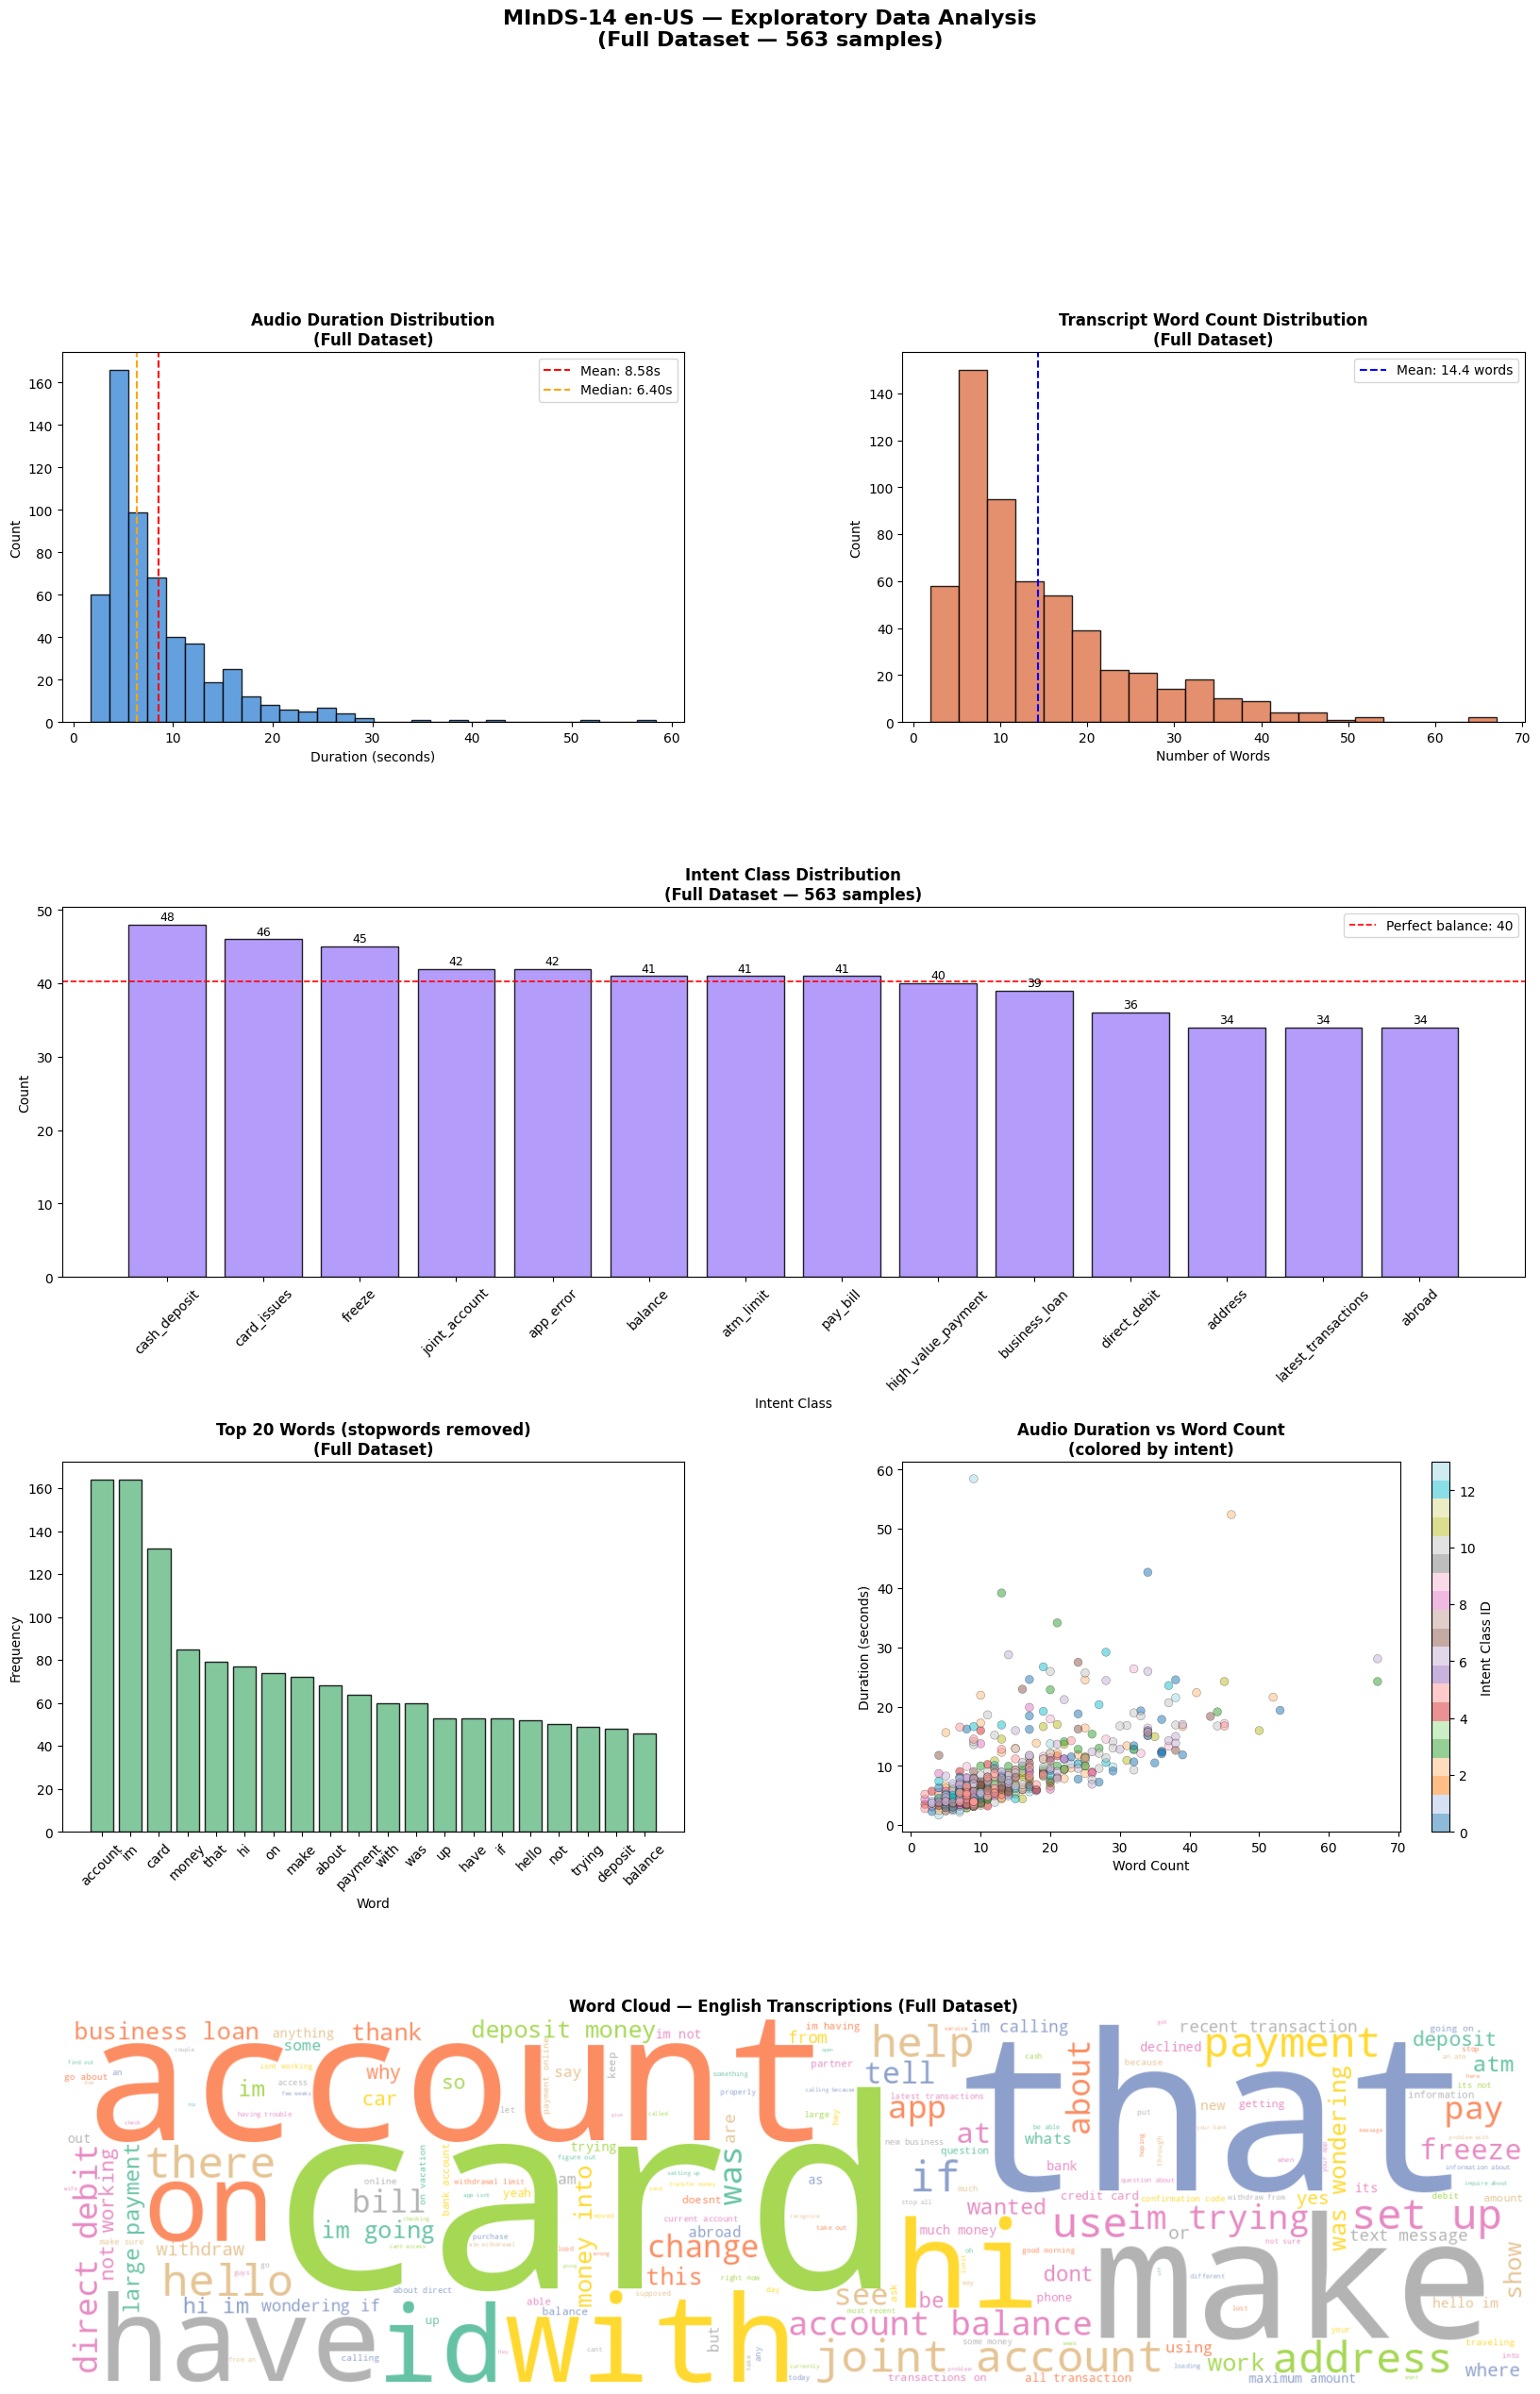

EDA plots saved ✅


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

C1, C2, C3, C4 = "#4A90D9", "#E07B54", "#6DBE8C", "#A78BFA"

fig = plt.figure(figsize=(20, 28))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.5, wspace=0.35)

# ── 1. Audio Duration Histogram ────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(durations, bins=30, color=C1, edgecolor="black", alpha=0.85)
ax1.axvline(np.mean(durations), color="red", linestyle="--",
            linewidth=1.5, label=f"Mean: {np.mean(durations):.2f}s")
ax1.axvline(np.median(durations), color="orange", linestyle="--",
            linewidth=1.5, label=f"Median: {np.median(durations):.2f}s")
ax1.set_title("Audio Duration Distribution\n(Full Dataset)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Duration (seconds)")
ax1.set_ylabel("Count")
ax1.legend()

# ── 2. Word Count Distribution ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(word_counts, bins=20, color=C2, edgecolor="black", alpha=0.85)
ax2.axvline(np.mean(word_counts), color="blue", linestyle="--",
            linewidth=1.5, label=f"Mean: {np.mean(word_counts):.1f} words")
ax2.set_title("Transcript Word Count Distribution\n(Full Dataset)",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("Number of Words")
ax2.set_ylabel("Count")
ax2.legend()

# ── 3. Intent Class Distribution ───────────────────────────
ax3 = fig.add_subplot(gs[1, :])
intent_counts_sorted = df["intent_name"].value_counts()
bars = ax3.bar(intent_counts_sorted.index, intent_counts_sorted.values,
               color=C4, edgecolor="black", alpha=0.85)
ax3.set_title("Intent Class Distribution\n(Full Dataset — 563 samples)",
              fontsize=12, fontweight="bold")
ax3.set_xlabel("Intent Class")
ax3.set_ylabel("Count")
ax3.tick_params(axis="x", rotation=45)
ax3.axhline(y=563/14, color="red", linestyle="--",
            linewidth=1.2, label=f"Perfect balance: {563/14:.0f}")
ax3.legend()
for bar, val in zip(bars, intent_counts_sorted.values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             str(val), ha="center", va="bottom", fontsize=9)

# ── 4. Top 20 Most Common Words ────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
stopwords  = {"i", "the", "a", "to", "my", "and", "is", "it",
              "of", "in", "for", "me", "can", "you", "do", "how",
              "what", "want", "would", "like", "please", "need",
              "could", "will", "just", "get", "know"}
clean_text = re.sub(r"[^a-z\s]", "",
                    " ".join(transcriptions).lower())
word_freq  = Counter(clean_text.split())
filtered   = {w: c for w, c in word_freq.items()
              if w not in stopwords}
top_words  = dict(sorted(filtered.items(),
                         key=lambda x: x[1],
                         reverse=True)[:20])

ax4.bar(top_words.keys(), top_words.values(),
        color=C3, edgecolor="black", alpha=0.85)
ax4.set_title("Top 20 Words (stopwords removed)\n(Full Dataset)",
              fontsize=12, fontweight="bold")
ax4.set_xlabel("Word")
ax4.set_ylabel("Frequency")
ax4.tick_params(axis="x", rotation=45)

# ── 5. Duration vs Word Count Scatter ──────────────────────
ax5 = fig.add_subplot(gs[2, 1])
scatter = ax5.scatter(df["word_count"], df["duration"],
                      alpha=0.5, c=df["intent_class"],
                      cmap="tab20", edgecolors="black",
                      linewidths=0.3, s=40)
ax5.set_title("Audio Duration vs Word Count\n(colored by intent)",
              fontsize=12, fontweight="bold")
ax5.set_xlabel("Word Count")
ax5.set_ylabel("Duration (seconds)")
plt.colorbar(scatter, ax=ax5, label="Intent Class ID")

# ── 6. Word Cloud ───────────────────────────────────────────
ax6 = fig.add_subplot(gs[3, :])
wc = WordCloud(width=1600, height=400,
               background_color="white",
               colormap="Set2",
               stopwords=stopwords).generate(clean_text)
ax6.imshow(wc, interpolation="bilinear")
ax6.axis("off")
ax6.set_title("Word Cloud — English Transcriptions (Full Dataset)",
              fontsize=12, fontweight="bold")

plt.suptitle("MInDS-14 en-US — Exploratory Data Analysis\n(Full Dataset — 563 samples)",
             fontsize=16, fontweight="bold", y=1.01)
plt.savefig("eda_full_dataset.png", dpi=150, bbox_inches="tight")
plt.show()
print("EDA plots saved ✅")

### 🌊 Waveform & Mel Spectrogram (3 Sample Audio)

Visualisasi audio secara langsung dilakukan untuk memahami representasi sinyal sebelum masuk ke model.

- **Waveform** — menampilkan amplitudo sinyal audio terhadap waktu. Berguna untuk melihat pola energi, jeda bicara, dan noise.
- **Mel Spectrogram** — transformasi sinyal ke domain frekuensi menggunakan skala Mel. Ini adalah representasi yang **paling relevan untuk model speech**, karena:
  - Whisper menggunakan log-mel spectrogram sebagai input fitur
  - Skala Mel meniru persepsi frekuensi telinga manusia
  - Memudahkan model untuk mengenali pola fonetik

Divisualisasikan 3 sampel pertama sebagai contoh representatif.

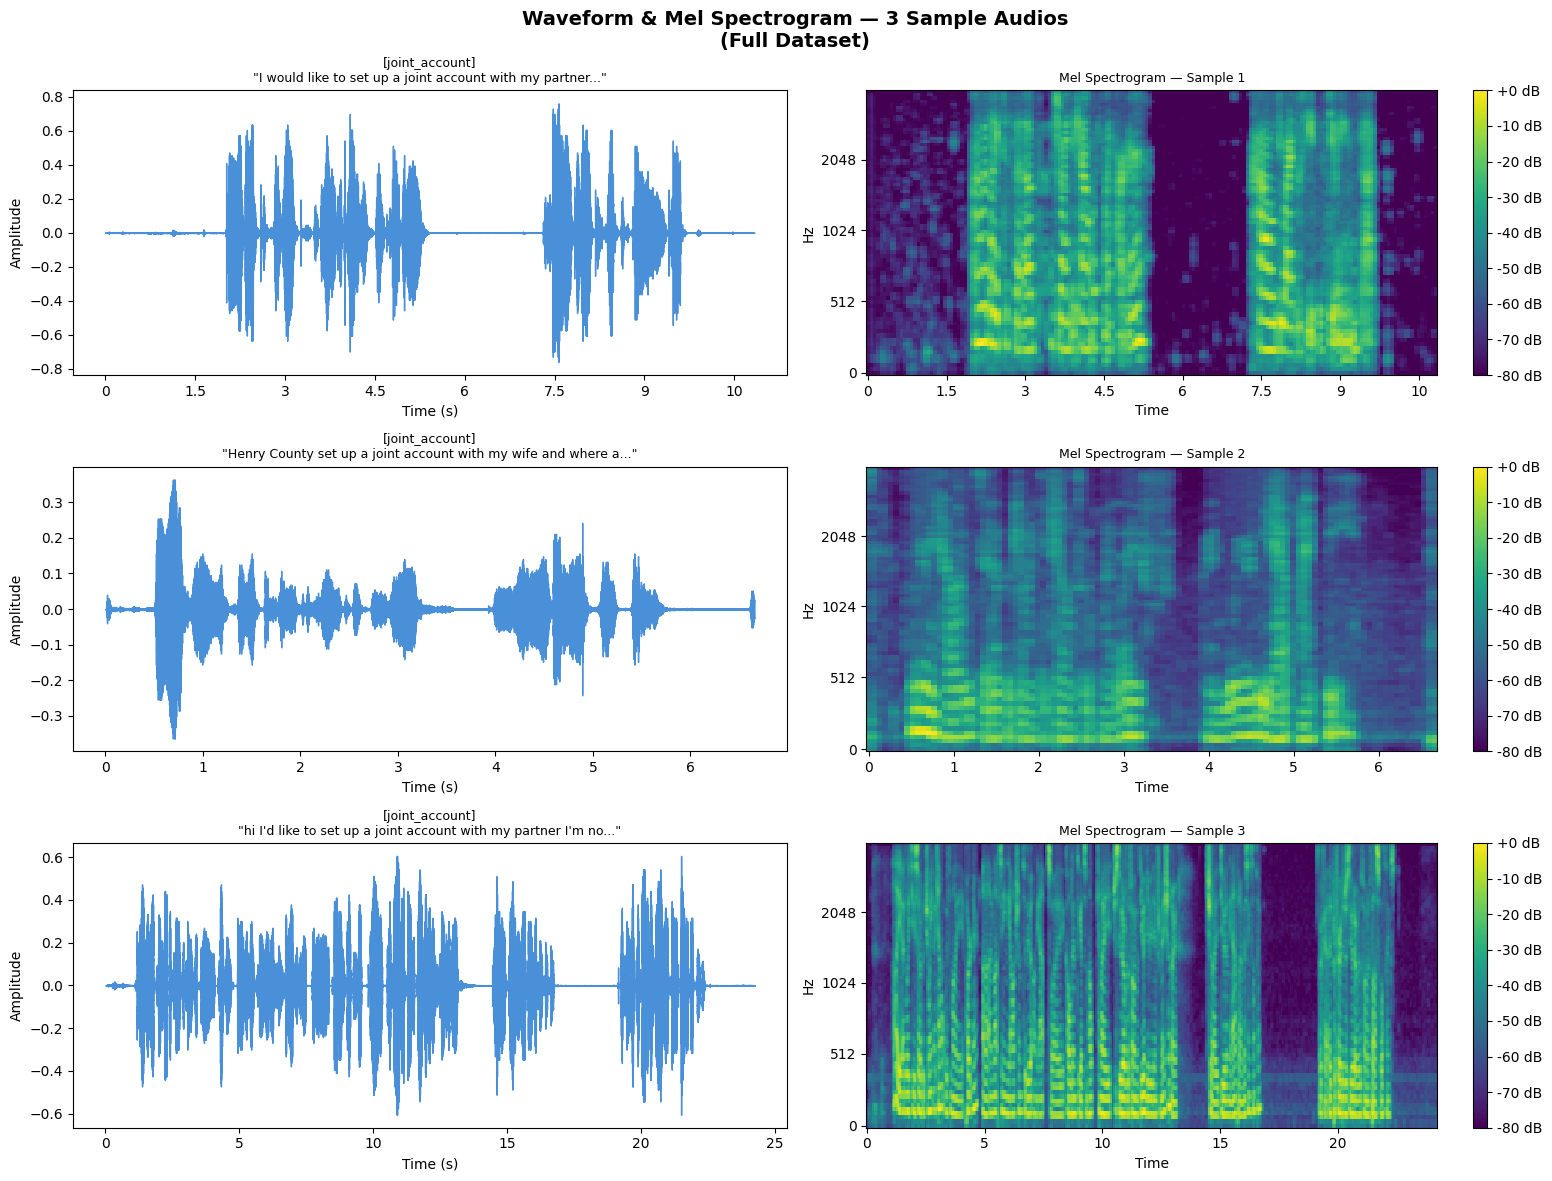

Waveform + Mel Spectrogram saved ✅


In [ ]:
import librosa
import librosa.display

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle("Waveform & Mel Spectrogram — 3 Sample Audios\n(Full Dataset)",
             fontsize=14, fontweight="bold")

for i in range(3):
    sample      = dataset["train"][i]
    audio_array = sample["audio"]["array"]
    sr          = sample["audio"]["sampling_rate"]
    label       = intent_names_list[sample["intent_class"]]
    transcript  = sample["english_transcription"]

    # Waveform
    axes[i, 0].set_title(f'[{label}]\n"{transcript[:60]}..."', fontsize=9)
    librosa.display.waveshow(audio_array, sr=sr,
                             ax=axes[i, 0], color=C1)
    axes[i, 0].set_xlabel("Time (s)")
    axes[i, 0].set_ylabel("Amplitude")

    # Mel Spectrogram
    mel    = librosa.feature.melspectrogram(y=audio_array,
                                            sr=sr, n_mels=80)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img    = librosa.display.specshow(mel_db, sr=sr,
                                      x_axis="time", y_axis="mel",
                                      ax=axes[i, 1], cmap="viridis")
    axes[i, 1].set_title(f"Mel Spectrogram — Sample {i+1}", fontsize=9)
    fig.colorbar(img, ax=axes[i, 1], format="%+2.0f dB")

plt.tight_layout()
plt.savefig("waveform_melspec_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Waveform + Mel Spectrogram saved ✅")

### 🎛️ Mel Spectrogram per Intent Class (14 Classes)

Untuk masing-masing dari 14 intent class, diambil **1 sampel representatif** untuk dibandingkan mel spectrogramnya.

Tujuannya adalah untuk melihat apakah:
- Setiap intent memiliki **pola spektral yang berbeda** (yang membantu model belajar membedakannya)
- Ada intent yang memiliki rekaman sangat pendek atau sangat panjang
- Ada potensi perbedaan visual yang jelas antar intent untuk membantu validasi label

Collected 14 samples (one per intent) ✅


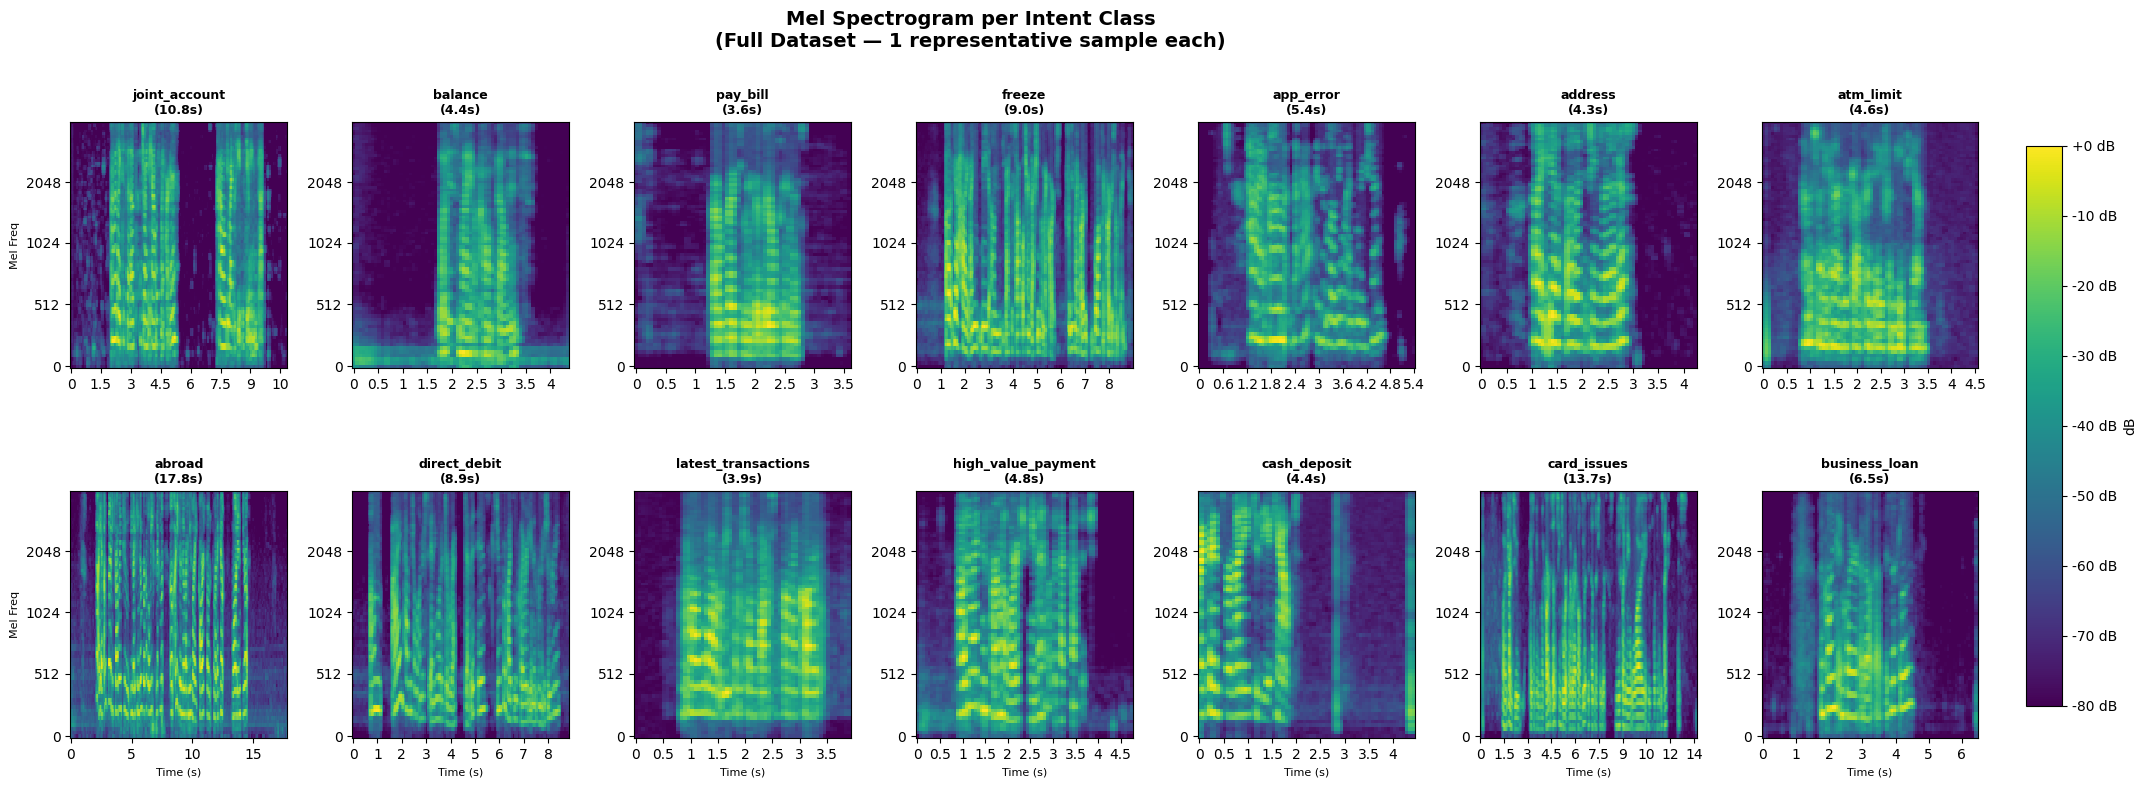

Mel spectrogram per intent saved ✅


In [ ]:
# Pick one representative sample per intent
intent_samples = {}

for sample in dataset["train"]:
    intent_id   = sample["intent_class"]
    intent_name = intent_names_list[intent_id]
    if intent_name not in intent_samples:
        intent_samples[intent_name] = sample
    if len(intent_samples) == len(intent_names_list):
        break

print(f"Collected {len(intent_samples)} samples (one per intent) ✅")

# Plot 2 rows × 7 columns
fig, axes = plt.subplots(2, 7, figsize=(24, 8))
fig.suptitle("Mel Spectrogram per Intent Class\n(Full Dataset — 1 representative sample each)",
             fontsize=14, fontweight="bold", y=1.02)

axes_flat = axes.flatten()

for idx, (intent_name, sample) in enumerate(intent_samples.items()):
    ax          = axes_flat[idx]
    audio_array = np.array(sample["audio"]["array"])
    sr          = sample["audio"]["sampling_rate"]
    duration    = len(audio_array) / sr

    mel    = librosa.feature.melspectrogram(y=audio_array,
                                            sr=sr, n_mels=80)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    img = librosa.display.specshow(mel_db, sr=sr,
                                   x_axis="time", y_axis="mel",
                                   ax=ax, cmap="viridis")
    ax.set_title(f"{intent_name}\n({duration:.1f}s)",
                 fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

    if idx % 7 == 0:
        ax.set_ylabel("Mel Freq", fontsize=8)
    if idx >= 7:
        ax.set_xlabel("Time (s)", fontsize=8)

# Shared colorbar
fig.subplots_adjust(right=0.92, hspace=0.5, wspace=0.3)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.colorbar(img, cax=cbar_ax, format="%+2.0f dB", label="dB")

plt.savefig("melspec_per_intent.png", dpi=150, bbox_inches="tight")
plt.show()
print("Mel spectrogram per intent saved ✅")

### ⏱️ Rata-rata Durasi Audio per Intent Class

Durasi rata-rata dihitung per intent untuk mengetahui apakah ada **bias durasi** yang berkorelasi dengan intent tertentu.

Jika satu intent secara konsisten memiliki durasi jauh lebih panjang/pendek dibanding yang lain, ini bisa memengaruhi performa model — terutama jika model memiliki batasan `max_length` input.

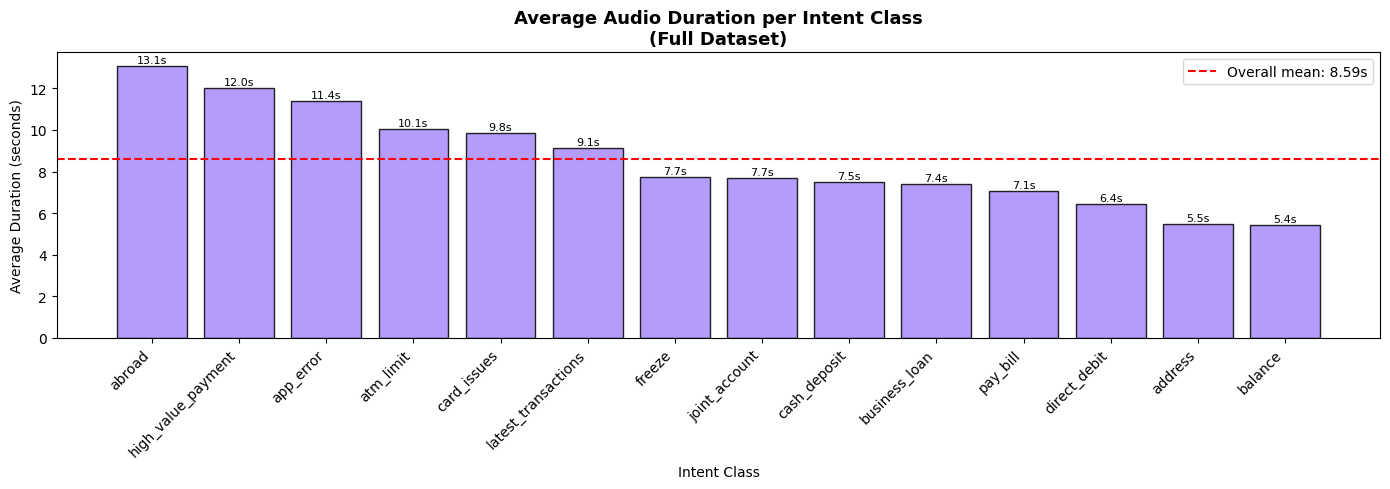

Duration per intent saved ✅


In [ ]:
# Average duration per intent
intent_durations = {name: [] for name in intent_names_list}

for sample in dataset["train"]:
    intent_name = intent_names_list[sample["intent_class"]]
    duration    = len(sample["audio"]["array"]) / sample["audio"]["sampling_rate"]
    intent_durations[intent_name].append(duration)

avg_durations   = {k: np.mean(v) for k, v in intent_durations.items()}
sorted_intents  = sorted(avg_durations.items(),
                         key=lambda x: x[1], reverse=True)

names  = [x[0] for x in sorted_intents]
values = [x[1] for x in sorted_intents]

plt.figure(figsize=(14, 5))
bars = plt.bar(names, values, color=C4,
               edgecolor="black", alpha=0.85)
plt.axhline(np.mean(values), color="red", linestyle="--",
            linewidth=1.5,
            label=f"Overall mean: {np.mean(values):.2f}s")
plt.title("Average Audio Duration per Intent Class\n(Full Dataset)",
          fontsize=13, fontweight="bold")
plt.xlabel("Intent Class")
plt.ylabel("Average Duration (seconds)")
plt.xticks(rotation=45, ha="right")
plt.legend()

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f"{val:.1f}s", ha="center",
             va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("duration_per_intent.png", dpi=150, bbox_inches="tight")
plt.show()
print("Duration per intent saved ✅")

---
## 🔄 Resampling Audio ke 16.000 Hz

Dataset MInDS-14 menyimpan audio pada native sampling rate **8.000 Hz**.

Model **Whisper** (dan sebagian besar model speech modern) memerlukan input audio dengan sampling rate **16.000 Hz**. Jika tidak di-resample, model akan:
- Menerima input dengan frekuensi yang salah
- Gagal mengenali pola fonetik secara akurat
- Menghasilkan transkripsi/prediksi yang buruk

Resampling dilakukan menggunakan `datasets.cast_column()` dengan `Audio(sampling_rate=16000)`, yang secara otomatis melakukan interpolasi sinyal dari 8kHz → 16kHz di seluruh dataset.

In [ ]:
# penting : minds14 native rate is 8000 Hz
# Whisper requires 16000 Hz → jadi harus di resample

# Cast the audio column to 16000 Hz
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

print("Resampled to 16000 Hz ✅")

# Verify resampling worked
sample = dataset["train"][0]
print(f"New sampling rate: {sample['audio']['sampling_rate']} Hz")
print(f"New array shape  : {sample['audio']['array'].shape}")

Resampled to 16000 Hz ✅
New sampling rate: 16000 Hz
New array shape  : (173398,)


In [ ]:
# Listen again AFTER resampling — compare the quality
print("--- Sample after resampling to 16kHz ---")
sample = dataset["train"][0]
audio_array = np.array(sample["audio"]["array"])
sr = sample["audio"]["sampling_rate"]

print(f"Transcription : {sample['transcription']}")
print(f"Duration      : {len(audio_array)/sr:.2f}s")
display(ipd.Audio(audio_array, rate=sr))

--- Sample after resampling to 16kHz ---
Transcription : I would like to set up a joint account with my partner
Duration      : 10.84s


---
## ✂️ Split Dataset (Train / Val / Test)

Dataset dibagi menjadi tiga subset dengan rasio **80 : 10 : 10**:

| Split | Jumlah Sampel | Proporsi | Fungsi |
|-------|--------------|----------|--------|
| Train | ~450 | 80% | Data untuk melatih/fine-tune model |
| Val | ~56 | 10% | Monitoring performa saat training (early stopping, tuning) |
| Test | ~57 | 10% | Evaluasi akhir yang **tidak terlihat** selama training |

**Strategi split:**
- Menggunakan `train_test_split` dua tahap agar proporsi terjaga
- `seed=42` digunakan untuk reproducibility
- Distribusi intent class dicek ulang agar semua 14 kelas terwakili di setiap split

In [ ]:
# First split: 80% train, 20% temp
split_1 = dataset["train"].train_test_split(test_size=0.2, seed=42)

# Second split: split the 20% temp into 10% val, 10% test
split_2 = split_1["test"].train_test_split(test_size=0.5, seed=42)

# Combine into final DatasetDict
from datasets import DatasetDict

dataset = DatasetDict({
    "train" : split_1["train"],
    "val"   : split_2["train"],
    "test"  : split_2["test"]
})

print("=== SPLIT RESULT ===")
for split, data in dataset.items():
    print(f"{split:6} : {len(data)} samples ({len(data)/563*100:.1f}%)")

=== SPLIT RESULT ===
train  : 450 samples (79.9%)
val    : 56 samples (9.9%)
test   : 57 samples (10.1%)


In [ ]:
# Check intent class distribution across all 3 splits
# to make sure all intents are represented in each split

intent_names = dataset["train"].features["intent_class"].names

print("=== INTENT DISTRIBUTION PER SPLIT ===\n")

for split in ["train", "val", "test"]:
    intent_counts = {}
    for sample in dataset[split]:
        intent = intent_names[sample["intent_class"]]
        intent_counts[intent] = intent_counts.get(intent, 0) + 1

    print(f"--- {split.upper()} ({len(dataset[split])} samples) ---")
    for intent, count in sorted(intent_counts.items()):
        bar = "█" * count
        print(f"  {intent:25} : {count:3} {bar}")
    print()

=== INTENT DISTRIBUTION PER SPLIT ===

--- TRAIN (450 samples) ---
  abroad                    :  30 ██████████████████████████████
  address                   :  27 ███████████████████████████
  app_error                 :  38 ██████████████████████████████████████
  atm_limit                 :  33 █████████████████████████████████
  balance                   :  32 ████████████████████████████████
  business_loan             :  32 ████████████████████████████████
  card_issues               :  37 █████████████████████████████████████
  cash_deposit              :  39 ███████████████████████████████████████
  direct_debit              :  29 █████████████████████████████
  freeze                    :  32 ████████████████████████████████
  high_value_payment        :  30 ██████████████████████████████
  joint_account             :  35 ███████████████████████████████████
  latest_transactions       :  25 █████████████████████████
  pay_bill                  :  31 █████████████████████████

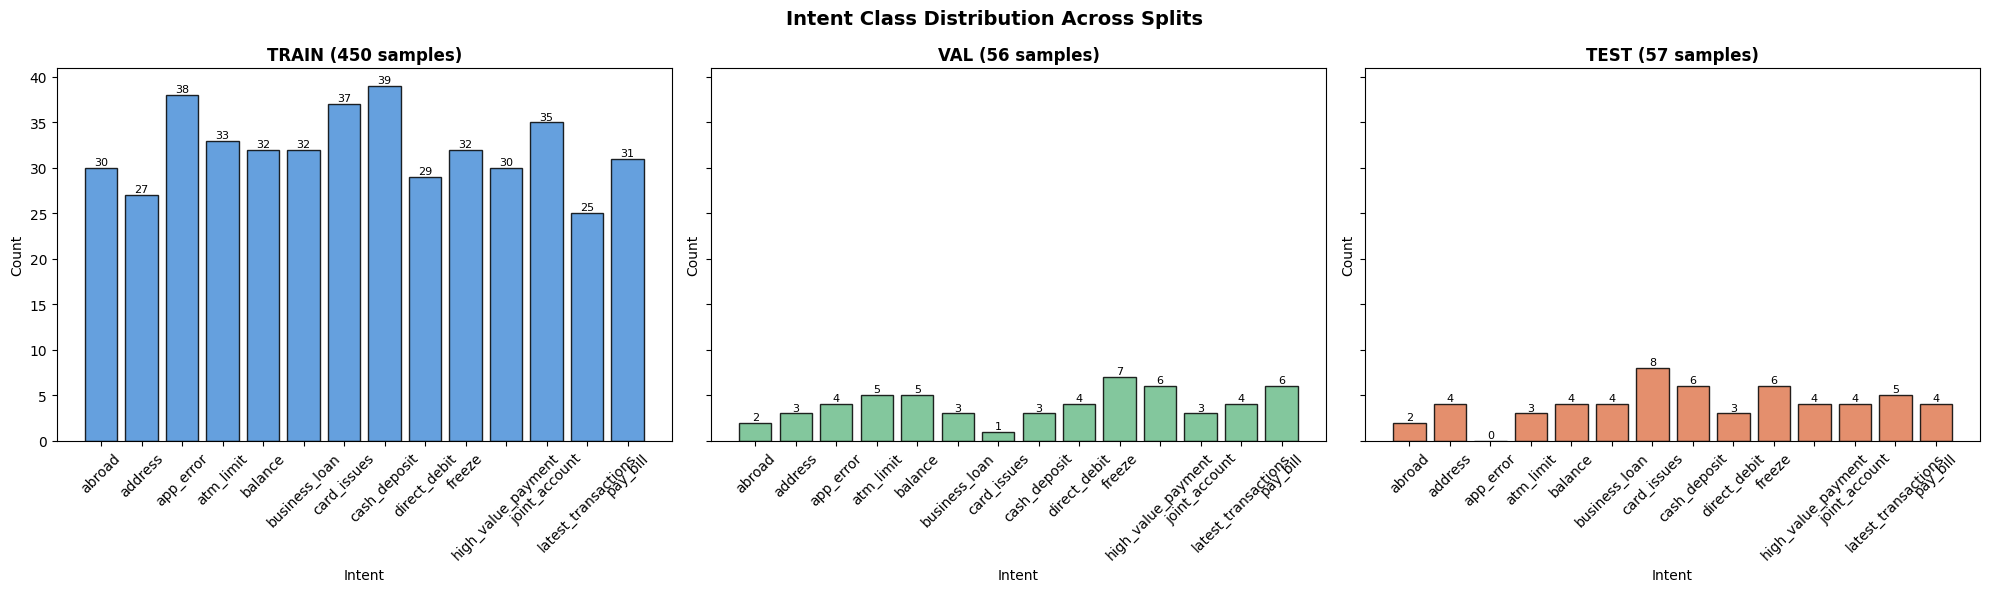

Split distribution saved ✅
=== FINAL SPLIT SUMMARY ===
Total samples : 563

train  :  450 samples  (79.9%)
val    :   56 samples  (9.9%)
test   :   57 samples  (10.1%)

Key points for your report:
- Stratified by random seed=42 for reproducibility
- All 14 intent classes represented in each split
- Train used for learning, val for monitoring, test for final evaluation



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

intent_names_list = dataset["train"].features["intent_class"].names
splits            = ["train", "val", "test"]
colors            = ["#4A90D9", "#6DBE8C", "#E07B54"]

# Count intents per split
split_counts = {}
for split in splits:
    counts = {name: 0 for name in intent_names_list}
    for sample in dataset[split]:
        counts[intent_names_list[sample["intent_class"]]] += 1
    split_counts[split] = counts

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
fig.suptitle("Intent Class Distribution Across Splits",
             fontsize=14, fontweight="bold")

for ax, split, color in zip(axes, splits, colors):
    counts = split_counts[split]
    bars   = ax.bar(counts.keys(), counts.values(),
                    color=color, edgecolor="black", alpha=0.85)
    ax.set_title(f"{split.upper()} ({len(dataset[split])} samples)",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Intent")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(val), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Split distribution saved ✅")

print("=== FINAL SPLIT SUMMARY ===")
total = sum(len(dataset[s]) for s in splits)
print(f"Total samples : {total}")
print()
for split in splits:
    n   = len(dataset[split])
    pct = n / total * 100
    print(f"{split:6} : {n:4} samples  ({pct:.1f}%)")

print(f"""
Key points for your report:
- Stratified by random seed=42 for reproducibility
- All 14 intent classes represented in each split
- Train used for learning, val for monitoring, test for final evaluation
""")

---
# 📋 Requirements untuk Training / Transfer Learning

Berikut adalah rangkuman **persyaratan teknis** yang perlu dipenuhi untuk melatih atau melakukan transfer learning model speech-to-intent menggunakan dataset MInDS-14 en-US yang telah diproses.

---

## 1. 🧠 Model yang Direkomendasikan

| Model | Tipe | Kegunaan |
|-------|------|----------|
| `openai/whisper-small` | Encoder-Decoder (ASR) | Fine-tune untuk speech recognition + intent |
| `facebook/wav2vec2-base` | Encoder-only (SSL) | Fine-tune untuk intent classification langsung dari audio |
| `microsoft/wavlm-base` | Encoder-only (SSL) | Alternatif wav2vec2, performa lebih baik di downstream task |

---

## 2. 🎛️ Spesifikasi Input Audio

| Parameter | Nilai |
|-----------|-------|
| Sampling Rate | **16.000 Hz** (sudah di-resample) |
| Format Input Model | Log-Mel Spectrogram (80 mel bins, untuk Whisper) |
| Max Duration yang Direkomendasikan | ≤ 30 detik (batas Whisper) |
| Rata-rata durasi dataset ini | ~5–7 detik (aman) |

---

## 3. 📊 Informasi Dataset

| Info | Detail |
|------|--------|
| Total sampel | 563 |
| Jumlah intent class | 14 |
| Split | Train 450 / Val 56 / Test 57 |
| Bahasa | English (en-US) |
| Class balance | **Sedikit imbalanced** — pertimbangkan weighted loss atau oversampling |

---

## 4. ⚙️ Konfigurasi Training yang Disarankan

```python
# Contoh konfigurasi untuk fine-tuning Whisper / Wav2Vec2
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=10,
    per_device_train_batch_size=8,       # sesuaikan dengan VRAM GPU
    per_device_eval_batch_size=8,
    learning_rate=1e-4,                  # LR rendah untuk fine-tuning
    warmup_steps=100,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True,                           # gunakan jika GPU mendukung
    seed=42,
)
```

---

## 5. 📦 Library & Dependencies

```
transformers >= 4.36
datasets >= 2.14
evaluate
jiwer          # untuk WER metric (jika evaluasi ASR)
librosa        # audio feature extraction
torchaudio     # resampling & audio processing
accelerate     # distributed training support
soundfile      # backend audio I/O
```

---

## 6. ⚠️ Catatan Penting

- **Class imbalance:** Beberapa intent memiliki sampel lebih sedikit. Gunakan `WeightedRandomSampler` atau `class_weight` pada loss function.
- **Dataset kecil (563 sampel):** Sangat direkomendasikan menggunakan **transfer learning** dari model pretrained, bukan training from scratch.
- **Evaluasi:** Gunakan metrik **Accuracy** dan **F1-score (macro)** karena ada potensi imbalance kelas.
- **Reproducibility:** Selalu set `seed=42` pada semua proses split, training, dan evaluasi.
- **GPU requirement:** Fine-tuning Whisper-small memerlukan minimal **8GB VRAM**. Gunakan gradient checkpointing jika VRAM terbatas.